In [1]:
import nugget
import numpy as np
import importlib
import pickle
import torch
import matplotlib.pyplot as plt
import os
import scipy

In [2]:
device = 'cuda:2'
lightsabre_surrogate = nugget.surrogates.LightSabre.LightSabre(device=device, use_poisson=False, domain_size=2500)
light_yield_surrogate = lightsabre_surrogate.light_yield_surrogate
signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(
                                        device=device, 
                                        event_type='signal', 
                                        domain_size=2500, 
                                        E_min=1e2, 
                                        E_max=1e8, 
                                        find_exact_intersection=True, 
                                        random_position_along_ray=False, 
                                        energy_dist='log_uniform',
                                        cylinder_center=torch.tensor([0.0, 0.0, 0.0]),
                                        cylinder_radius=600.0,
                                        cylinder_height=1000.0,
                                        # cos_range=torch.tensor((np.cos(np.pi/2),np.cos(np.pi/2)))
                                        )

In [3]:
llr_net = nugget.surrogates.LLRnet.LLRnet(
        device=device,
        domain_size=(600*2,1000),  # Size of the detector domain
        dim=3,  # 3D spatial coordinates
        hidden_dims=[64, 64, 64, 64],  # Neural network architecture
        use_fourier_features=False,  # Use Fourier features for better spatial encoding
        num_parallel_branches=1,  # Multiple branches for ensemble learning
        frequency_scales=[0.1, 0.4],  # Different frequency scales for fourier features
        num_frequencies_per_branch=[64,64],  # Number of Fourier features per branch
        learnable_frequencies=False,  # Fixed frequency features
        dropout_rate=0,  # Regularization
        learning_rate=1e-3,  # Optimizer learning rate
        shared_mlp=False,  # Independent MLPs for each branch
        use_residual_connections=True,  # Skip connections for better training
        signal_noise_scale=0,  # Noise level for signal events
        background_noise_scale=0.2,  # Noise level for background events
        add_relative_pos=False,  # Whether to include relative position features
        log_scale_ly=True,  # Whether to log-scale the light yield inputs
        norm_pos=True,  # Whether to normalize position inputs
        log_scale_energy=True,  # Whether to log-scale the energy inputs
        add_distance_from_beam=False,  # Whether to include distance from beam as a feature
        reduce_lr_on_plateau=True,  # Reduce learning rate on plateau
        lr_scheduler_patience=35,  # Patience for LR scheduler
    )
llr_net.load_model('best_charge_llr_model_v2')

Building parallel network architecture:
  Input dim: 11
  Number of parallel branches: 1
  Shared MLP: False
  Branch 0 MLP with residual connections: 11 -> [64, 64, 64, 64] -> 64
  Final MLP: 64 -> 32 -> 1
  Total trainable parameters: 19,521


In [4]:
importlib.reload(nugget.utils.basic_evaluator)
importlib.reload(nugget.utils.vis_tools)
importlib.reload(nugget.geometries.DynamicString)
geometry = nugget.geometries.DynamicString.DynamicString(
            device=device,
            hex_type='hexagonal',
            domain_size=1200,  # Size of detector domain
            dim=3,  # 3D geometry
            n_strings=70,  # Initial number of detector strings (ignore)
            points_per_string=20,  # Number of OMs per string
            custom_z_spacing=50, # OM spacing along string
            random_xy=True,  # Randomize XY positions of strings
        )

visualizer = nugget.utils.vis_tools.Visualizer(
    device=device,
    dim=3, 
    domain_size=1600,
    gif_temp_dir='./gif_temp',
    )

optimizer = nugget.utils.basic_optimizer.Optimizer(
    device=geometry.device, 
    geometry=geometry,
    visualizer=visualizer,
    conflict_free=False,  # Single-objective optimization (vs multi-objective)
    use_custom_cf_weight=False,
    use_alm=True,  # Use Augmented Lagrangian Method for constraints
    sigmoid_losses=True,
    sigmoid_softness=1,
     alm_params={
        'gamma': 1e-2,
        'alpha': 0.95,
        'epsilon': 1e-8,
        # 'lambda_min': 0,   # Minimum value for Lagrange multipliers
        # 'lambda_max': 100,    # Maximum value for Lagrange multipliers
        # 'mu_min': 1e-3,       # Minimum value for penalty parameters
        # 'mu_max': 10         # Maximum value for penalty parameters
    }
)
# exp_scheduler = nugget.utils.schedulers.CosineScheduler
# Initialize the geometry with optimization parameters
# string_weights controls which strings are active (learnable parameter)
optimizer.init_geometry(
    # opt_list=[('string_spacing', 0.01)],  # Learning rate for string positions
    opt_list=[('string_xy', 2)],  # Learning rate for string weights (without sigmoid applied)
)

Optimizing string_xy with torch.Size([70, 2]) shape


In [5]:
# test_signal_events = pickle.load(open('/u/kristiantcho/ptmp/nugget/nugget/examples/res_test/signal_events_10000_r600_50_1.pkl', 'rb'))

In [ ]:
importlib.reload(nugget.losses.geometry_penalties)
importlib.reload(nugget.losses.fisher_info)
rov_penalty = nugget.losses.geometry_penalties.ROVPenalty(
    device=geometry.device, 
    rov_rec_width=230,  # ROV dimensions
    rov_height=159.9, 
    rov_tri_length=159.9
)

angular_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    device=geometry.device,
    # device="cuda:3",
    resolution_type='angular',
    fisher_info_params=['position','energy', 'direction']
)

local_string_repulsion_penalty = nugget.losses.geometry_penalties.LocalStringRepulsionPenalty(
    device=geometry.device
)
# pointsource_fom_loss = nugget.losses.pointsource_fom.FoMLoss(
#     device=geometry.device,
#     fisher_info_params=['position','energy', 'direction']
# )

loss_params ={
    'signal_sampler': signal_sampler,
    'max_radius': 25,  # Maximum radius for sampling events and evaluating responses
    'num_angles': 360,  # Number of angles (divided into 360 degrees) to test for rov
    'num_events':100,
    'rov_alt_mode': False,  # Whether to use alternative mode for rov penalty (see rov_penalty.py for details)
    'rov_soft_inside':True,
    'rov_inside_sharpness': 5,
    'rov_angle_softmin_tau': -1,
    'signal_surrogate_func': light_yield_surrogate,
    # 'signal_event_params': test_signal_events,
    'perfect_efficiency': True,
    'bounding_cylinder_temperature': 0.1,
    'per_effective_area_loss': True,
    'skip_zero_response': True,
    # 'fisher_info_llr_net': llr_net,
    'use_relative_energy': True,
    'fisher_info_detach_tensors': False,  # Whether to detach tensors when computing Fisher information (can reduce memory usage but may affect gradients)
    'fisher_info_llr_iteratrions': 100,  # Number of iterations to train LLR net for each Fisher information calculation
    'fisher_info_params': ['position','energy', 'direction'],
    'fisher_info_grad_chunk_size': 7,  # Chunk size for computing gradients of Fisher information (adjust based on memory)
    'fisher_info_jacrev_chunk_size': 50000,  # Chunk size for computing Jacobians of Fisher information (adjust based on memory)
    'fisher_info_point_chunk_size': 14000,  # Chunk size for processing events when computing Fisher information (adjust based on memory)
    'fisher_info_llr_autodiff_mode': 'jvp',  # Method for computing gradients of log-likelihood ratio ('grad' or 'jacrev')
    'boundary_sharpness': 10,  # Sharpness parameter for boundary penalty
    'constraints_list': [
                # 'energy_resolution_loss',
                # 'angular_resolution_loss',
                # 'signal_yield_loss', 
                'rov_penalty', 
                'string_boundary_penalty', 
                'local_string_repulsion_penalty', 
                'string_number_penalty', 
                # 'string_weights_penalty',
                'weighted_binarization_penalty'
                ],  # Constraints to enforce
}


loss_func_dict = {
    # 'rov_penalty': rov_penalty,
    'angular_resolution_loss': angular_resolution_loss,
    'local_string_repulsion_penalty': local_string_repulsion_penalty,
    # 'pointsource_fom_loss': pointsource_fom_loss
}
loss_weights_dict = {
    'angular_resolution_loss': 1e3,
    'pointsource_fom_loss': 5e1,
    # 'energy_resolution_loss': 0.5,
    # 'fisher_loss': 0.005, 
    'signal_yield_loss': 0.01,        # High weight: maximize light collection
    # 'signal_llr_loss': 2.5,          # Moderate weight: good signal discrimination
    'string_boundary_penalty': 2,  # Very high: hard constraint
    'local_string_repulsion_penalty': 5,
    # 'string_repulsion_penalty': 0.000001,
    # 'string_weights_penalty': 0,     # Encourage sparse solutions
    'string_weights_penalty': 0.05,     # Encourage sparse solutions
    'string_number_penalty': 1,      # Limit detector complexity
    'weight_binarization_penalty': 0.1,
    'rov_penalty': 1
}

loss_sigmoid_list = [
    'pointsource_fom_loss',
    'angular_resolution_loss',
    # 'energy_resolution_loss',
    # 'fisher_loss', 
    # 'signal_yield_loss',        # High weight: maximize light collection
    # 'signal_llr_loss',
    'string_boundary_penalty',  # Very high: hard constraint
    'local_string_repulsion_penalty',
    # 'string_repulsion_penalty': 0.000001,
    # 'string_weights_penalty': 0,     # Encourage sparse solutions
    'string_weights_penalty',     # Encourage sparse solutions
    'string_number_penalty',      # Limit detector complexity
    'weight_binarization_penalty',
    'rov_penalty'
]

plot_types = [
    'loss_components',           # Loss function values over time
    # 'uw_loss_components',        # Unweighted loss components
    # 'llr_histogram',           # LLR distributions
    # 'string_weights_scatter',    # String weight visualization
    # 'signal_llr_contour',        # LLR spatial distribution for signals
    # 'background_llr_contour',  # LLR spatial distribution for background
    # 'signal_light_yield_contour', # Light yield spatial distribution
    # 'fisher_info_contour',     # Fisher information distribution
    # 'angular_resolution_vs_zenith',      # Angular resolution maps
    # 'pointsource_fom_vs_energy',
    # 'energy_resolution_vs_energy',       # Energy resolution maps,
    '3d_points',
    'angular_resolution_vs_energy',
    # 'pointsource_fom',
    'angular_resolution',
    'string_xy',
    # 'string_xy_rov_penalty',
    'string_xy_local_string_repulsion_penalty',
    
    # 'signal_contour',
    # 'alm_mu',
    # 'alm_lambda'
]

vis_kwargs = {
    'plot_types': plot_types,
    'plot_3d_shift_left': 0.03,
    'slice_res': 51,             # Resolution of spatial plots
    'multi_slice': True,         # Generate multiple depth slices
    'gif_plot_selection': plot_types,  # Which plots to include in animation
    # 'loss_filter': ['string_boundary_penalty'],  # Hide large loss components from loss component plot
    # 'zoom_range':800,
    'signal_surrogate_func': light_yield_surrogate,
    'plot_with_surrogate': True,  # Use surrogate function for spatial plots
    # 'signal_yield_per_string': loss_params['precomputed_signal_yield_per_string'],  # Precomputed light yield for visualization
    'n_zenith_bins': 10,  # Binning for angular resolution plots
    'n_energy_bins': 10,   # Binning for energy resolution plots
    'draw_radius': True,
    'draw_weighted_cylinder': False,
    'max_radius': 600,
    'rov_penalty_func': rov_penalty,
    'use_relative_energy': True,
    'plot_geom_contour_only': True,
    'use_log_charge': True,
    'rov_draw_safe_space_on_violations':False,
    'resolution_stat': 'fom',  # Statistic to plot for resolution ('median' or 'mean')
}

In [7]:
string_xy = optimizer.geom_dict['string_xy'].detach().cpu().numpy()  # Get (x,y) positions of all strings
dists = np.linalg.norm(string_xy[:, None, :] - string_xy[None, :, :], axis=-1)  # Pairwise distances
print(min(dists[dists > 0]))  # Minimum non-zero distance between strings

19.439693


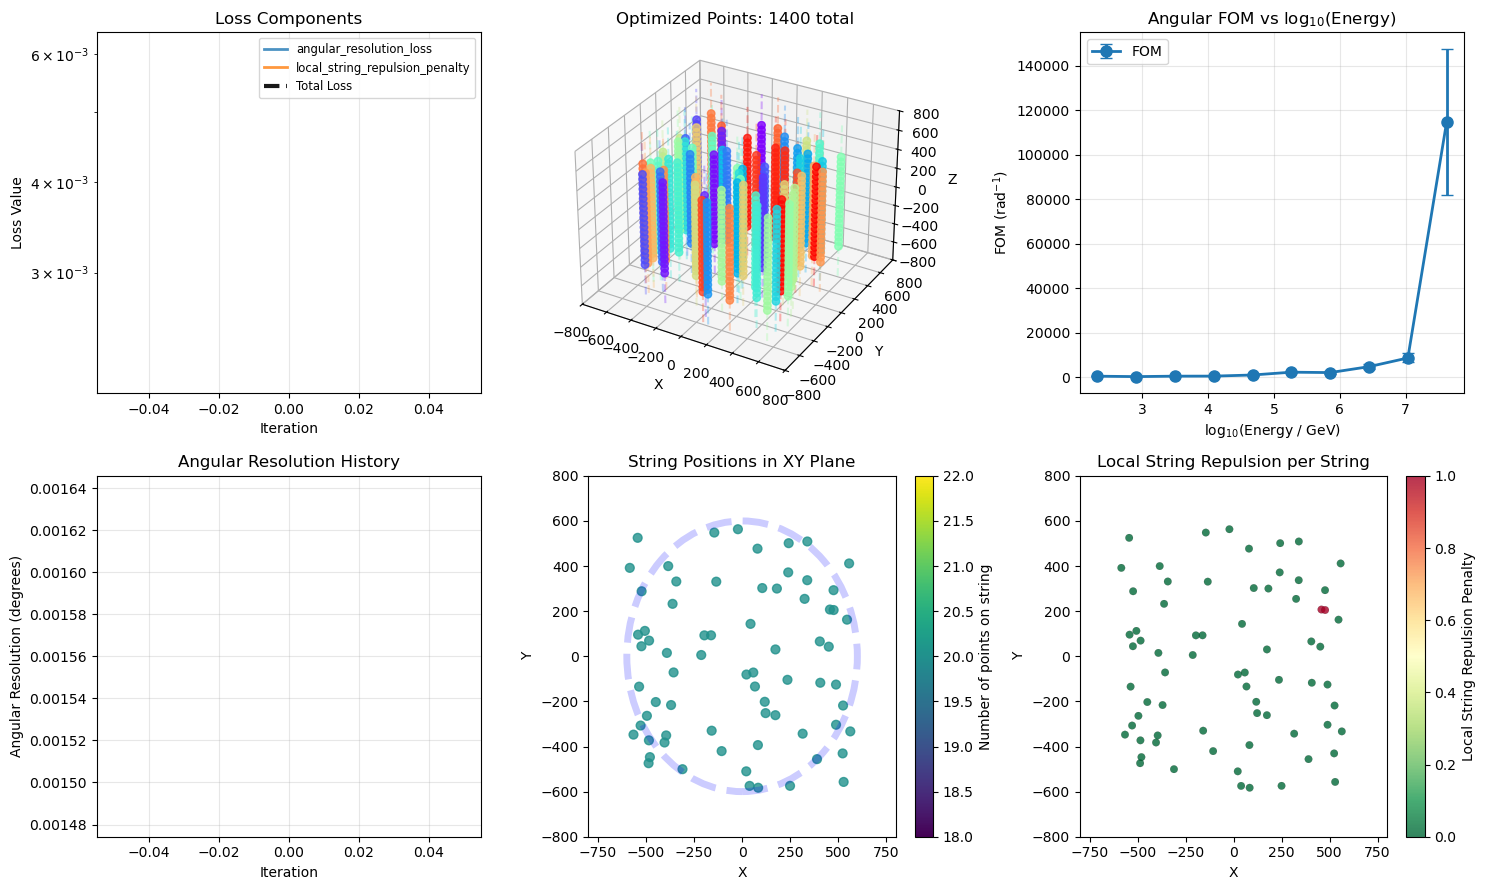

Saved GIF frame 1 to ./gif_temp/frame_0000.png


KeyboardInterrupt: 

In [10]:
torch.autograd.set_detect_anomaly(False)
optimizer.visualizer.cleanup_gif_temp_files()  # Clean up any old visualization files

geom_dict = optimizer.optimize(
    loss_func_dict=loss_func_dict,          # Dictionary of loss functions to use
    loss_weights_dict=loss_weights_dict,    # Weights for combining multiple losses
    loss_params_dict=loss_params,           # Parameters for loss function computation
    n_iter=2000,                           # Maximum number of optimization iterations
    vis_kwargs=vis_kwargs,                 # Visualization parameters
    print_freq=5,                          # Print progress every N iterations
    vis_freq=10,                           # Create plots every N iterations
    gif_freq=5,                           # Save animation frames every N iterations
    sigmoid_loss_list=loss_sigmoid_list,         # Which losses to apply sigmoid to (for better optimization dynamics)
    save_geom_folder='./ds70_r600_50_any_ang_res_rov',  # Directory to save geometry checkpoints
    save_geom_freq=100,                      # Save geometry every N iterations
    continue_saving=False,
    # save_best_geom_file = './best_geom_1_event.pkl',  # File to save best geometry found
    # save_last_geom = False, 
    # cf_loss_weights_dict=cf_loss_weights_dict,  # custom weights for conflict-free optimization
    # loss_dict=loss_dict,         # resupply loss histories if continuing optimization (only for visualization)
    # uw_loss_dict=uw_loss_dict,   
    # vis_loss_dict=vis_loss_dict, 
    # vis_uw_loss_dict=vis_uw_loss_dict  
)